# NuPlan Lane Graph — LTL Model Checking

Automata-theoretic model checking on NuPlan map data.
A Kripke model is built from a BFS lane subgraph; LTL formulas are checked via
the GPVW Büchi translation + Tarjan SCC emptiness test.
For pure LTL / Büchi examples see **visualize_LTL_buchi.ipynb**.


In [12]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import os, sys
import IPython.display as display

_d = os.path.abspath(os.getcwd())
while _d != os.path.dirname(_d) and not os.path.isdir(os.path.join(_d, 'tutorials', 'buchi')):
    _d = os.path.dirname(_d)
if _d not in sys.path:
    sys.path.insert(0, _d)

from tutorials.buchi import BuchiAutomaton, KripkeModel
from tutorials.buchi.visualization_graphviz import draw
from tutorials.buchi.nuplan_modelcheck import solve_for_path, visualize_solution, visualize_nodes
print('imports OK')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
imports OK


## 1. Kripke model from a NuPlan lane graph

A **Kripke model** `M = (S, →, L)` is the natural way to represent a road-network graph for temporal reasoning:
- **States** `S` = lane segments and lane connectors near the ego vehicle.
- **Transitions** `→` = the `outgoing_edges` connectivity in the NuPlan map.
- **Labelling** `L` is supplied by a user-defined function `node_to_props(node_id) → set[str]` that inspects each map object and returns the atomic propositions true there.

Propositions used here:

| Proposition | Meaning |
|-------------|---------|
| `lane` | Regular lane segment |
| `connector` | Lane connector (crosses an intersection) |
| `ego` | Ego vehicle's current lane/connector |
| `fork` | More than one outgoing edge (choice point) |


In [2]:
import networkx as nx
from nuplan.common.actor_state.state_representation import Point2D
from nuplan.common.maps.nuplan_map.map_factory import NuPlanMapFactory, get_maps_db

from tutorials.buchi.nuplan_graph import load_nuplan_subgraph
from tutorials.buchi.nuplan_scenarios import get_scenarios

# ── Load scenario & map once ─────────────────────────────────────────────────
scenario = get_scenarios(split='mini', scenario_types=['accelerating_at_traffic_light'])[1]
map_factory = NuPlanMapFactory(
    get_maps_db(map_root=scenario.map_root, map_version=scenario.map_version))
nuplan_map = map_factory.build_map_from_name(scenario.map_api.map_name)

ego_state = scenario.get_ego_state_at_iteration(0)
ego_point = Point2D(ego_state.rear_axle.x, ego_state.rear_axle.y)

# ── Example 1: radius = 200 m, depth = 10 ────────────────────────────────────
small_G, object_map, object_types, ego_id = load_nuplan_subgraph(nuplan_map, ego_point, radius=200, depth_limit=10)
print(f"Subgraph: {small_G.number_of_nodes()} nodes, {small_G.number_of_edges()} edges")
print(f"Ego node: {ego_id}")

Subgraph: 12 nodes, 11 edges
Ego node: 69518


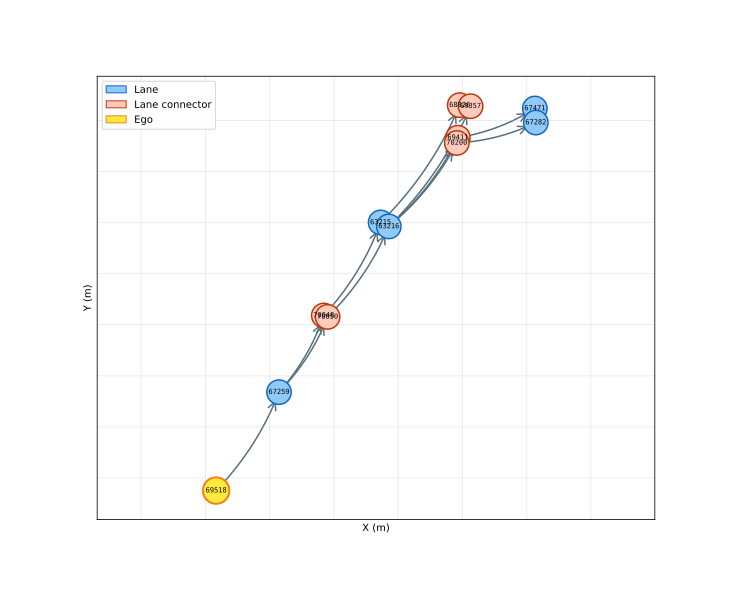

In [3]:
from tutorials.buchi.nuplan_graph import nuplan_pos, draw_nuplan_subgraph

pos = nuplan_pos(small_G, object_map)
draw_G = small_G.subgraph(pos.keys()).copy()

draw_nuplan_subgraph(draw_G, pos, object_types, ego_id,
                     title='NuPlan subgraph (NetworkX) — ego neighbourhood')

Kripke model: 12 states, 11 transitions

Propositions per state:
  63215: ['lane']
  63216: ['fork', 'lane']
  67259: ['fork', 'lane']
  67282: ['lane']
  67471: ['lane']
  68826: ['connector']
  69357: ['connector']
  69411: ['connector']
  69518: ['connector', 'ego']  [initial]
  70048: ['connector']
  70050: ['connector']
  70200: ['connector']


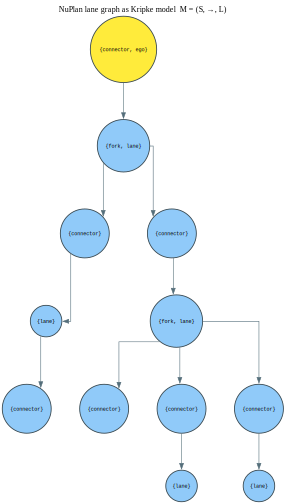

In [4]:
# ── User-defined proposition map ─────────────────────────────────────────────
def node_to_props(node_id: str) -> set:
    """
    Map a NuPlan lane-graph node ID to the atomic propositions holding there.

    This is the user-supplied labelling function L : S → 2^AP for the Kripke model.
    Modify or extend this function to encode any road-level predicates of interest.
    """
    props = set()
    props.add(object_types.get(node_id, 'unknown'))   # 'lane' or 'connector'
    if node_id == ego_id:
        props.add('ego')
    if small_G.out_degree(node_id) > 1:
        props.add('fork')
    return props

# ── Build Kripke model from the NuPlan subgraph ──────────────────────────────
kripke_nuplan = KripkeModel()

for node in small_G.nodes():
    props = node_to_props(node)
    if node == ego_id:
        kripke_nuplan.add_initial_state(node, props)
    else:
        kripke_nuplan.add_state(node, props)

for src, dst in small_G.edges():
    kripke_nuplan.add_transition(src, dst)

print(f"Kripke model: {len(kripke_nuplan.states)} states, "
      f"{sum(len(v) for v in kripke_nuplan._transitions.values())} transitions")
print("\nPropositions per state:")
for s in sorted(kripke_nuplan.states, key=str):
    marker = "  [initial]" if s in kripke_nuplan.initial_states else ""
    print(f"  {s}: {sorted(kripke_nuplan.labeling[s])}{marker}")

# ── Visualize ────────────────────────────────────────────────────────────────
g = draw(kripke_nuplan,
         title='NuPlan lane graph as Kripke model  M = (S, →, L)',
         node_propositions=node_to_props,
         show_edge_labels=False,
         use_xlabels=False,
         initial_color='#ffeb3b',
         size='10,7', nodesep=0.7, ranksep=0.9)
display.SVG(g.pipe(format='svg'))

## 2. Model checking made simple — `solve_for_path` + `visualize_solution`

The whole automata-theoretic pipeline (build the Kripke model → translate the LTL
formula to a Büchi automaton → form the product → run the SCC emptiness check →
project the lasso stem) is wrapped in a single library call.  Every example below
follows the same two-line pattern:

```python
solution = solve_for_path(graph, object_types, ego_id, pos, formula, prop_nodes)
if solution is not None:
    visualize_solution(solution, **flags)
```

- **`solve_for_path(...)`** returns a `PathSolution` (the witness path + context) when
  the specification is feasible, or **`None`** when it is infeasible.
- **`visualize_solution(solution, **flags)`** plots the path on the NuPlan subgraph;
  `flags` (`figsize`, `node_size`, `offpath_node_size`, `path_only`, `title`, …) are
  forwarded to the drawing routine.
- **`prop_nodes`** assigns the named atomic propositions used by the formula (e.g.
  `destination`, `waypoint`) to specific node IDs.  Structural propositions
  (`lane`, `connector`, `ego`, `fork`) are labelled automatically from the graph.

This first example: **φ = F(destination)** — *eventually reach node 67471* — on the
radius = 200 m, depth = 10 subgraph.


Formula:  F destination
B(φ): 3 states   M×B: 36 states, 70 transitions

RESULT: SAT — lasso stem (6 step(s)):
  step  0: 69518  ['connector', 'ego']  [initial]
  step  1: 67259  ['fork', 'lane']
  step  2: 70050  ['connector']
  step  3: 63216  ['fork', 'lane']
  step  4: 69411  ['connector']
  step  5: 67471  ['destination', 'lane']  [DESTINATION]
  step  6: 67471  ['destination', 'lane']  [DESTINATION]


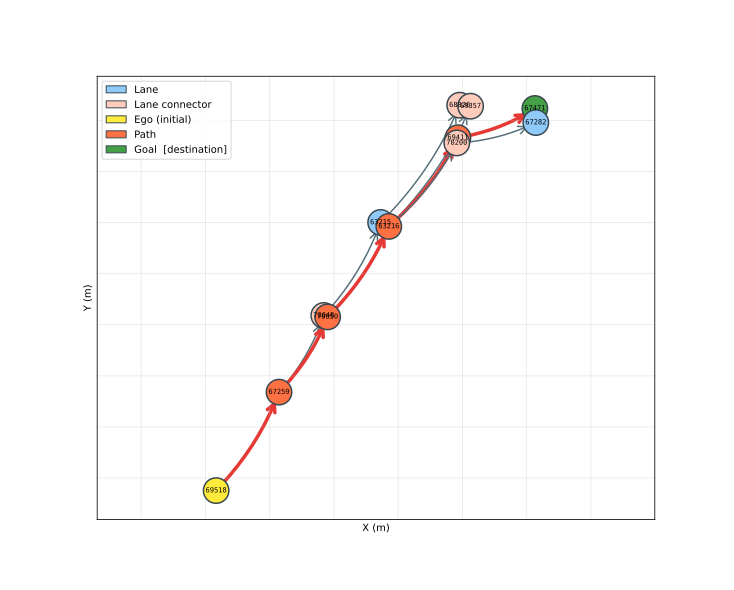

In [5]:
# ── Section 7: φ = F(destination) — eventually reach node 67471 (radius=200) ──
from tutorials.buchi import F, Var
from tutorials.buchi.nuplan_modelcheck import solve_for_path, visualize_solution, visualize_nodes

prop_nodes = {'destination': '67471'}
solution = solve_for_path(small_G, object_types, ego_id, pos,
                          F(Var('destination')), prop_nodes=prop_nodes)
if solution is not None:
    display.display(visualize_solution(
        solution, title='F(destination) — satisfying path to node 67471'))
else:
    display.display(visualize_nodes(
        small_G, object_types, ego_id, pos, prop_nodes,
        title='F(destination=67471)  [UNSAT] — node shown on the full graph'))

## 3. More formulae — same two-line pattern

Reusing the radius = 200 m subgraph (`small_G`, `object_types`, `ego_id`, `pos`), each
formula is checked and plotted with the same `solve_for_path` / `visualize_solution` pair.

| # | Formula | Reading |
|---|---------|---------|
| A | `F(fork)` | eventually reach a road fork (a decision point). |
| B | `F(lane ∧ ¬fork)` | eventually reach a plain lane — not a fork, not a connector. |


Formula:  F fork
B(φ): 3 states   M×B: 36 states, 76 transitions

RESULT: SAT — lasso stem (4 step(s)):
  step  0: 69518  ['connector', 'ego']  [initial]
  step  1: 67259  ['fork', 'lane']
  step  2: 70050  ['connector']
  step  3: 63216  ['fork', 'lane']
  step  4: 69357  ['connector']


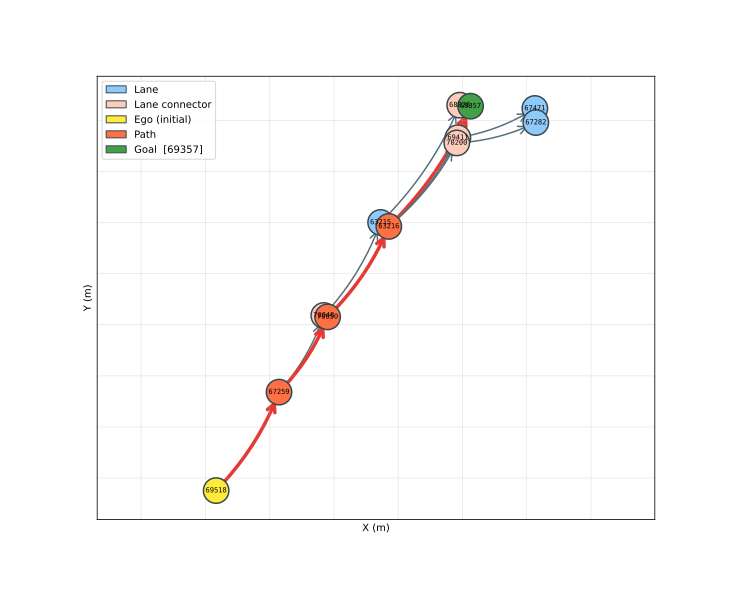

In [6]:
# φ_A = F(fork) — "eventually reach a road fork (decision point)"
from tutorials.buchi import F, Var

solution = solve_for_path(
    small_G, object_types, ego_id, pos,
    F(Var('fork')),
)
if solution is not None:
    display.display(visualize_solution(
        solution, title='φ = F(fork) — path to the first road fork'))

Formula:  F (lane ∧ ¬fork)
B(φ): 3 states   M×B: 36 states, 73 transitions

RESULT: SAT — lasso stem (4 step(s)):
  step  0: 69518  ['connector', 'ego']  [initial]
  step  1: 67259  ['fork', 'lane']
  step  2: 70048  ['connector']
  step  3: 63215  ['lane']
  step  4: 68826  ['connector']


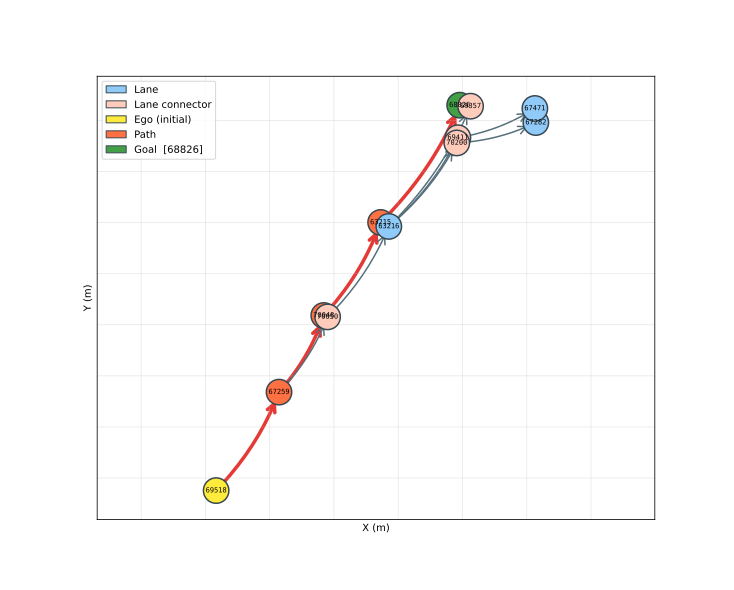

In [18]:
# φ_B = F(lane ∧ ¬fork) — "eventually reach a plain lane (not a fork, not a connector)"
from tutorials.buchi import F, And, Not, Var

solution = solve_for_path(
    small_G, object_types, ego_id, pos,
    F(And(Var('lane'), Not(Var('fork')))),
)
if solution is not None:
    display.display(visualize_solution(
        solution, title='φ = F(lane ∧ ¬fork) — path to a plain lane'))

## 4. Larger subgraph: radius = 500 m, depth = 30

A wider map query (`radius=500`) and deeper BFS (`depth_limit=30`) yield a larger Kripke
model. We check **φ = F(destination)** for destination node **67377**, reusing the same
two-line API on the bigger graph (`small_G_2`, `object_types_2`, `ego_id_2`, `pos_2`).


In [7]:
# ── Load the larger subgraph ──────────────────────────────────────────────────
small_G_2, object_map_2, object_types_2, ego_id_2 = load_nuplan_subgraph(nuplan_map, ego_point, radius=500, depth_limit=30)
print(f"Subgraph: {small_G_2.number_of_nodes()} nodes, {small_G_2.number_of_edges()} edges")
print(f"Ego node: {ego_id_2}")
print("\nAll node IDs (type):")
for n in sorted(small_G_2.nodes(), key=str):
    marker = "  ← ego" if n == ego_id_2 else ""
    print(f"  {n}  ({object_types_2.get(n, 'unknown')}){marker}")

Subgraph: 31 nodes, 31 edges
Ego node: 69518

All node IDs (type):
  63215  (lane)
  63216  (lane)
  64381  (lane)
  64386  (lane)
  64437  (connector)
  64438  (connector)
  67213  (lane)
  67259  (lane)
  67279  (lane)
  67282  (lane)
  67308  (lane)
  67340  (lane)
  67377  (lane)
  67467  (lane)
  67471  (lane)
  67512  (lane)
  67534  (lane)
  68667  (connector)
  68826  (connector)
  68836  (connector)
  69357  (connector)
  69411  (connector)
  69518  (connector)  ← ego
  69558  (connector)
  69776  (connector)
  69800  (connector)
  69823  (connector)
  69847  (connector)
  70048  (connector)
  70050  (connector)
  70200  (connector)


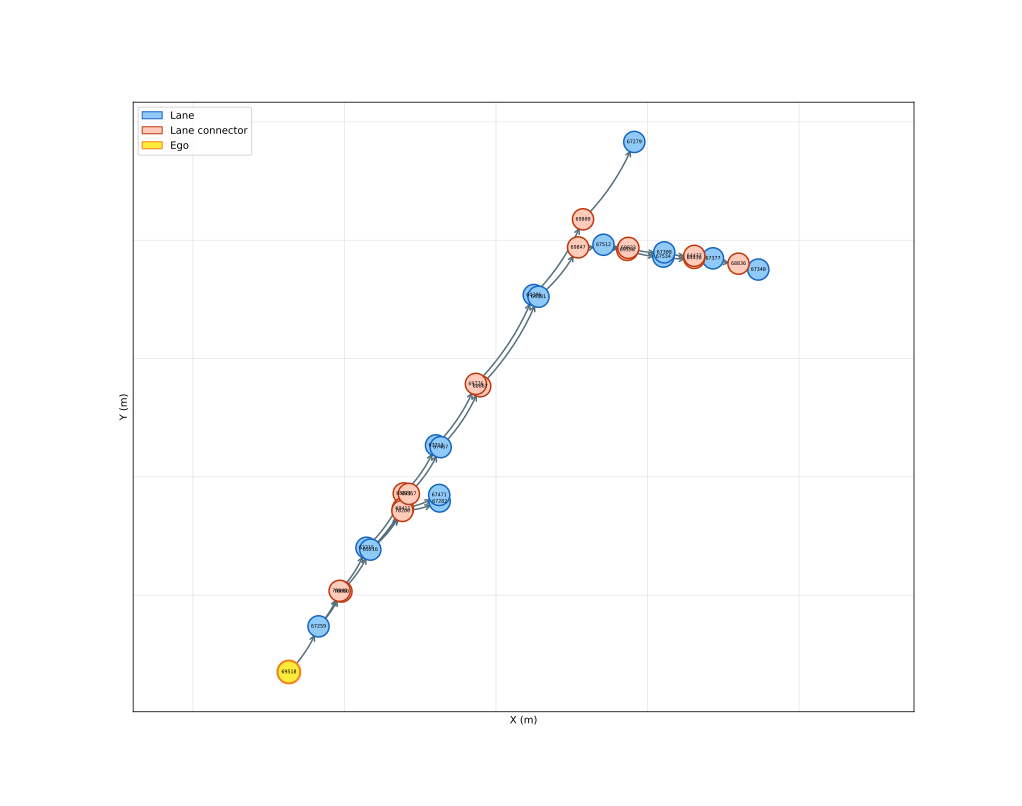

In [8]:
from tutorials.buchi.nuplan_graph import nuplan_pos, draw_nuplan_subgraph

pos_2 = nuplan_pos(small_G_2, object_map_2)
draw_G_2 = small_G_2.subgraph(pos_2.keys()).copy()

draw_nuplan_subgraph(draw_G_2, pos_2, object_types_2, ego_id_2,
                     title='NuPlan subgraph (radius=500 m, depth=30) — ego neighbourhood',
                     figsize=(14, 11), node_size=450, arrowsize=12, font_size=5)

Formula:  F destination
B(φ): 3 states   M×B: 93 states, 188 transitions

RESULT: SAT — lasso stem (15 step(s)):
  step  0: 69518  ['connector', 'ego']  [initial]
  step  1: 67259  ['fork', 'lane']
  step  2: 70050  ['connector']
  step  3: 63216  ['fork', 'lane']
  step  4: 69357  ['connector']
  step  5: 67467  ['lane']
  step  6: 68667  ['connector']
  step  7: 64381  ['lane']
  step  8: 69847  ['connector']
  step  9: 67512  ['fork', 'lane']
  step 10: 69558  ['connector']
  step 11: 67534  ['lane']
  step 12: 64438  ['connector']
  step 13: 67377  ['destination', 'lane']  [DESTINATION]
  step 14: 68836  ['connector']
  step 15: 67340  ['lane']


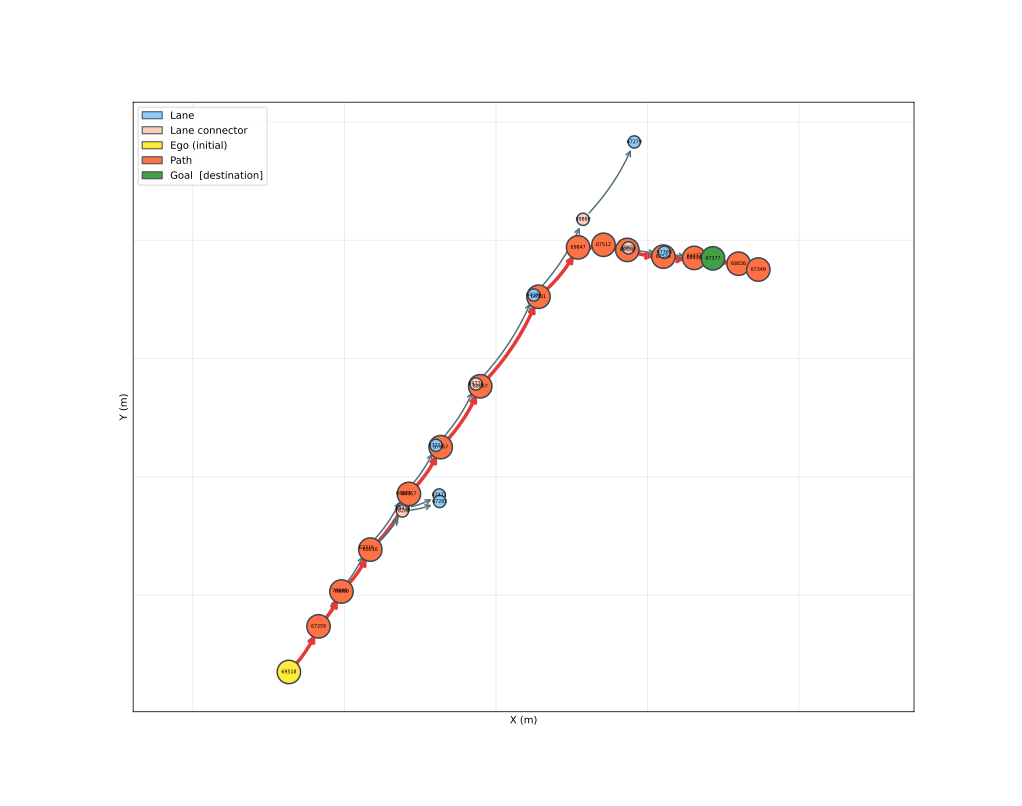

In [21]:
# ── F(destination) check — destination = node 67377 (radius=500, depth=30) ──
from tutorials.buchi import F, Var

prop_nodes = {'destination': '67377'}
solution = solve_for_path(small_G_2, object_types_2, ego_id_2, pos_2,
                          F(Var('destination')), prop_nodes=prop_nodes)
if solution is not None:
    display.display(visualize_solution(
        solution, figsize=(14, 11), node_size=550, offpath_node_size=150,
        font_size=5, arrowsize=12,
        title='F(destination=67377) — satisfying path (radius=500 m, depth=30)'))
else:
    display.display(visualize_nodes(
        small_G_2, object_types_2, ego_id_2, pos_2, prop_nodes, figsize=(14, 11),
        title='F(destination=67377)  [UNSAT] — node shown on the full graph'))

## 5. Nested reachability: `F(waypoint ∧ F(G(destination)))`

φ = **F(waypoint ∧ F(G(destination)))** — *eventually reach the waypoint, and from there
eventually always reach the destination*. The inner `F(G(destination))` is only
"activated" once the ego visits a `waypoint` state.

Subgraph: radius = 1000 m, depth = 100 (700 nodes). Waypoint = **68571**, destination = **67337**.
The witness path is drawn on its own (`path_only=True`) since the full graph is too dense to read.


In [9]:
# ── Step 0: load subgraph (radius=1000 m, depth=100) ─────────────────────────
from tutorials.buchi.nuplan_graph import nuplan_pos

small_G_3, object_map_3, object_types_3, ego_id_3 = load_nuplan_subgraph(
    nuplan_map, ego_point, radius=1000, depth_limit=100)
print(f"Subgraph: {small_G_3.number_of_nodes()} nodes, {small_G_3.number_of_edges()} edges  |  ego: {ego_id_3}")

pos_3    = nuplan_pos(small_G_3, object_map_3)
draw_G_3 = small_G_3.subgraph(pos_3.keys()).copy()

Subgraph: 700 nodes, 741 edges  |  ego: 69518


Formula:  F (waypoint ∧ F G destination)
B(φ): 12 states   M×B: 8400 states, 14434 transitions

RESULT: SAT — lasso stem (37 step(s)):
  step  0: 69518  ['connector', 'ego']  [initial]
  step  1: 67259  ['fork', 'lane']
  step  2: 70048  ['connector']
  step  3: 63215  ['lane']
  step  4: 68826  ['connector']
  step  5: 67213  ['lane']
  step  6: 69776  ['connector']
  step  7: 64386  ['lane']
  step  8: 69800  ['connector']
  step  9: 67279  ['fork', 'lane']
  step 10: 69001  ['connector']
  step 11: 63253  ['fork', 'lane']
  step 12: 69085  ['connector']
  step 13: 67554  ['lane']
  step 14: 69724  ['connector']
  step 15: 67571  ['lane']
  step 16: 70085  ['connector']
  step 17: 67359  ['fork', 'lane']
  step 18: 70262  ['connector']
  step 19: 68554  ['lane']
  step 20: 70465  ['connector']
  step 21: 68571  ['fork', 'lane', 'waypoint']  [WAYPOINT]
  step 22: 69608  ['connector']
  step 23: 63366  ['lane']
  step 24: 64282  ['connector']
  step 25: 67415  ['fork', 'lane']
  step 2

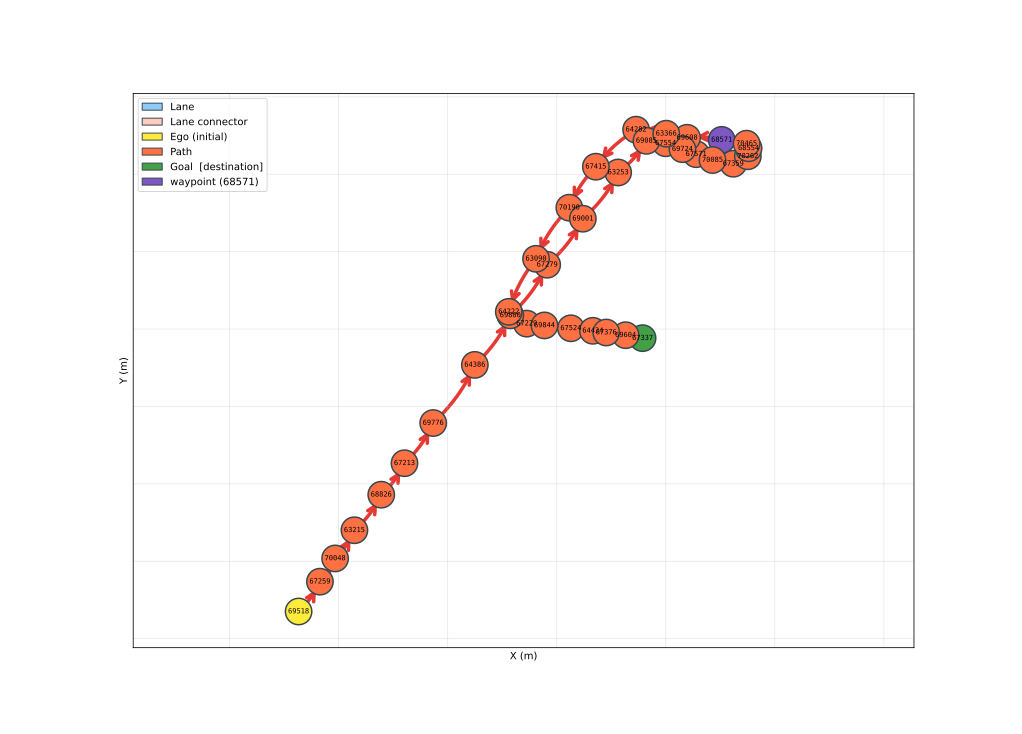

In [10]:
# φ = F(waypoint ∧ F(G(destination))) — waypoint 68571, destination 67337
from tutorials.buchi import F, G, And, Var

prop_nodes = {'waypoint': '68571', 'destination': '67337'}
solution = solve_for_path(
    small_G_3, object_types_3, ego_id_3, pos_3,
    F(And(Var('waypoint'), F(G(Var('destination'))))),
    prop_nodes=prop_nodes,
)
if solution is not None:
    display.display(visualize_solution(
        solution, path_only=True, figsize=(14, 10), node_size=700,
        title='φ = F(68571 ∧ F(G(67337)))  [SAT]'))
else:
    display.display(visualize_nodes(
        small_G_3, object_types_3, ego_id_3, pos_3, prop_nodes,
        title='φ = F(68571 ∧ F(G(67337)))  [UNSAT] — nodes on the full graph'))

## 6. Feasible vs infeasible nested queries

Same large subgraph as section 5 (700 nodes), same two-line API. Formula shape:
**φ = F(node_A ∧ F(G(node_B)))**.

| # | Formula | Expected | Notes |
|---|---------|----------|-------|
| 6a | `F(64385 ∧ F(G(63680)))` | **SAT** | 64385 reaches 63680; witness plotted by `visualize_solution` |
| 6b | `F(67341 ∧ F(G(68280)))` | **UNSAT** | 68280 not reachable from 67341; nodes shown on full graph |


Formula:  F (waypoint ∧ F G destination)
B(φ): 12 states   M×B: 8400 states, 14426 transitions

RESULT: SAT — lasso stem (115 step(s)):
  step  0: 69518  ['connector', 'ego']  [initial]
  step  1: 67259  ['fork', 'lane']
  step  2: 70048  ['connector']
  step  3: 63215  ['lane']
  step  4: 68826  ['connector']
  step  5: 67213  ['lane']
  step  6: 69776  ['connector']
  step  7: 64386  ['lane']
  step  8: 69800  ['connector']
  step  9: 67279  ['fork', 'lane']
  step 10: 69001  ['connector']
  step 11: 63253  ['fork', 'lane']
  step 12: 69085  ['connector']
  step 13: 67554  ['lane']
  step 14: 69724  ['connector']
  step 15: 67571  ['lane']
  step 16: 70085  ['connector']
  step 17: 67359  ['fork', 'lane']
  step 18: 70262  ['connector']
  step 19: 68554  ['lane']
  step 20: 70465  ['connector']
  step 21: 68571  ['fork', 'lane']
  step 22: 69608  ['connector']
  step 23: 63366  ['lane']
  step 24: 64282  ['connector']
  step 25: 67415  ['fork', 'lane']
  step 26: 70452  ['connector']

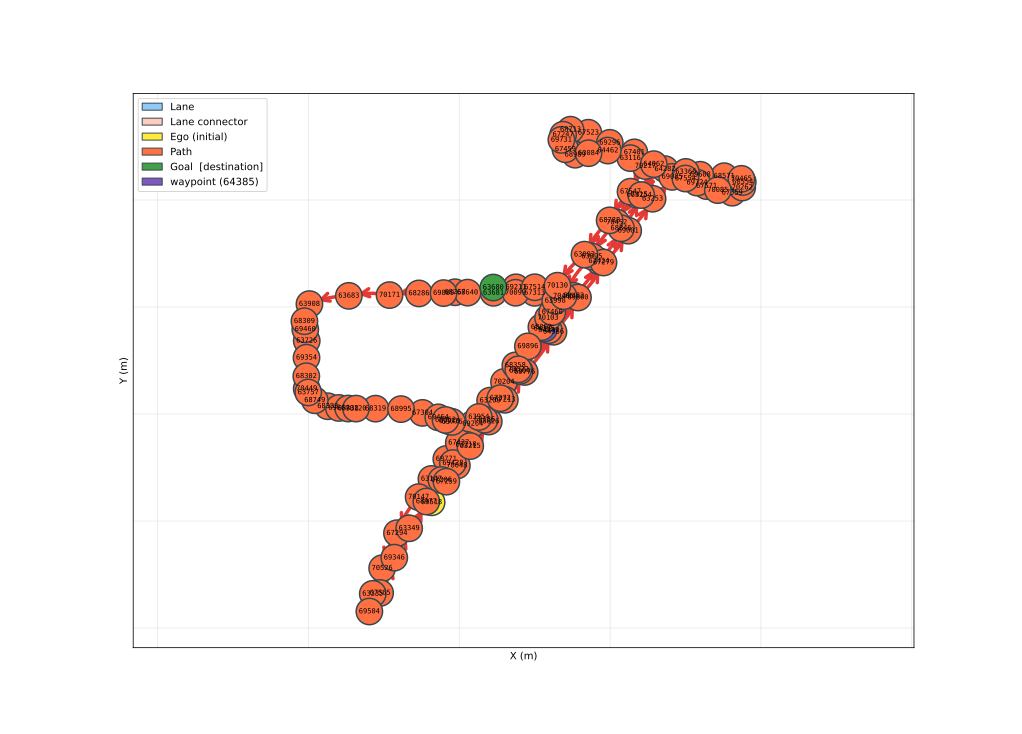

In [11]:
# ── 11a: F(64385 ∧ F(G(63680))) — FEASIBLE (64385 reaches 63680) ──
from tutorials.buchi import F, G, And, Var

prop_nodes = {'waypoint': '64385', 'destination': '63680'}
solution = solve_for_path(
    small_G_3, object_types_3, ego_id_3, pos_3,
    F(And(Var('waypoint'), F(G(Var('destination'))))),
    prop_nodes=prop_nodes,
)
if solution is not None:
    display.display(visualize_solution(
        solution, path_only=True, figsize=(14, 10), node_size=700,
        title=f'φ = F({prop_nodes["waypoint"]} ∧ F(G({prop_nodes["destination"]})))  [SAT]'))
else:
    print('Infeasible — showing the two nodes on the overall NuPlan graph.')
    display.display(visualize_nodes(
        small_G_3, object_types_3, ego_id_3, pos_3, prop_nodes,
        title=f'φ = F({prop_nodes["waypoint"]} ∧ F(G({prop_nodes["destination"]})))  [UNSAT] — nodes on the full graph'))

Formula:  F (waypoint ∧ F G destination)
B(φ): 12 states   M×B: 8400 states, 14426 transitions

RESULT: UNSAT — φ is not satisfiable on this model (no execution trace satisfies the specification).
Infeasible — showing the two nodes on the overall NuPlan graph.


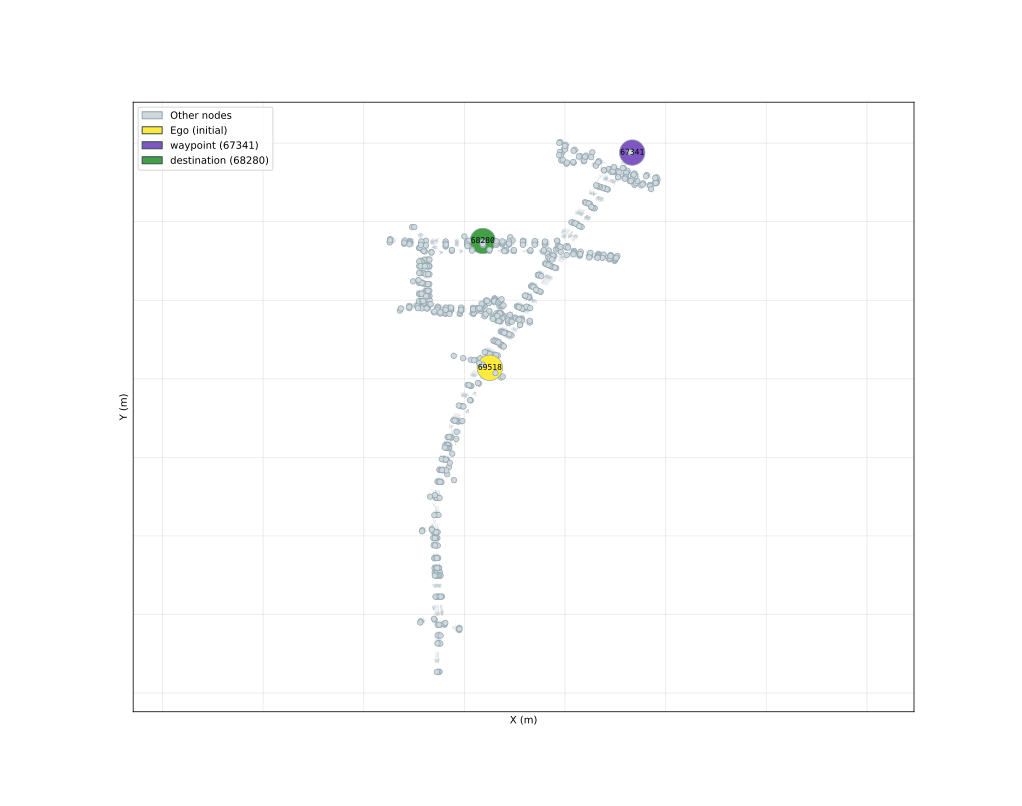

In [ ]:
# ── 11b: F(67341 ∧ F(G(68280))) — infeasible (68280 unreachable from 67341) ─
from tutorials.buchi import F, G, And, Var

prop_nodes = {'waypoint': '67341', 'destination': '68280'}
solution = solve_for_path(
    small_G_3, object_types_3, ego_id_3, pos_3,
    F(And(Var('waypoint'), F(G(Var('destination'))))),
    prop_nodes=prop_nodes,
)
if solution is not None:
    display.display(visualize_solution(
        solution, path_only=True, figsize=(14, 10), node_size=700,
        title=f'φ = F({prop_nodes["waypoint"]} ∧ F(G({prop_nodes["destination"]})))'))
else:
    print('Infeasible — showing the two nodes on the overall NuPlan graph.')
    display.display(visualize_nodes(
        small_G_3, object_types_3, ego_id_3, pos_3, prop_nodes,
        title=f'φ = F({prop_nodes["waypoint"]} ∧ F(G({prop_nodes["destination"]})))  [UNSAT] — nodes on the full graph'))

## 7. Animate the traversal — `animate_solution`

Turn a static witness into a **node-by-node traversal video**. `animate_solution`
walks the lasso stem one node per frame with a **sliding highlight window**: the
current node is drawn crimson, the previous `window − 1` nodes trail behind it in
orange, and earlier nodes fade back to their base style — so the highlighted band
slides along the route like a comet. The goal stays green and the ego yellow, exactly
as in `visualize_solution`.

```python
solution = solve_for_path(graph, object_types, ego_id, pos, formula, prop_nodes)
animate_solution(solution, window=3, fps=2, output_path='traversal.mp4')   # H.264 video
```

| Flag | Effect |
|------|--------|
| `window` | trailing-highlight length; `1` = spotlight only the current node |
| `fps` | playback / video frame rate |
| `path_only` | draw only the path's nodes (recommended for large graphs) |
| `label_window_only` | label only the lit nodes each frame (keeps long paths legible) |
| `output_path` | write a file — `.mp4` (H.264 via ffmpeg) or `.gif` (Pillow) |

The call returns an inline player either way: a `Video` for a written `.mp4`/`.gif`,
or a self-contained HTML5/JS player when no `output_path` is given.


In [16]:
# ── Animate the witness as a sliding-window traversal video ───────────────────
# animate_solution(solution, window=W) walks the lasso stem one node per frame:
#   • the current node is crimson, the previous (W-1) nodes trail behind in orange,
#   • earlier nodes fade back to their base style so the highlighted band *slides*,
#   • goal stays green and ego yellow — same palette as visualize_solution.
# output_path='....mp4' writes an H.264 video via ffmpeg; the call returns an inline
# player (a Video for .mp4 / .gif, or an HTML5/JS player when no file is written).
from tutorials.buchi import F, Var
from tutorials.buchi.nuplan_modelcheck import solve_for_path, animate_solution

solution = solve_for_path(small_G, object_types, ego_id, pos,
                          F(Var('destination')), prop_nodes={'destination': '67471'},
                          verbose=False)
# window=3 → a 3-node comet tail; fps=2 → two nodes per second.
animate_solution(solution, window=3, fps=2,
                 output_path='traversal.mp4',
                 title='F(destination=67471) — node-by-node traversal')

# Other options:
#   animate_solution(solution, window=1)                  # spotlight only the current node
#   animate_solution(solution, window=len(solution.path)) # keep the whole travelled prefix lit
#   animate_solution(solution, path_only=True, label_window_only=True)  # for large graphs
#   animate_solution(solution, fps=2)                     # inline player, no file written
#   animate_solution(solution, output_path='traversal.gif')  # GIF instead of MP4

rendered animation to traversal.mp4


### Animating a long witness — example 6a

The same `animate_solution` call scales to the 115-step witness of **6a**
(`φ = F(64385 ∧ F(G(63680)))`) on the 700-node subgraph. For a route this long,
`path_only=True` draws only the traversed nodes and `label_window_only=True` labels
just the lit window each frame, so the crimson head and its orange trail stay
readable as they sweep from the ego through the waypoint to the destination.


In [17]:
# ── Animate example 6a: F(64385 ∧ F(G(63680))) on the 700-node graph ──────────
# A long 115-step witness, so draw only the route (path_only=True) and label only
# the lit nodes each frame (label_window_only=True) to keep the sliding window legible.
from tutorials.buchi import F, G, And, Var
from tutorials.buchi.nuplan_modelcheck import solve_for_path, animate_solution

prop_nodes = {'waypoint': '64385', 'destination': '63680'}
solution_6a = solve_for_path(
    small_G_3, object_types_3, ego_id_3, pos_3,
    F(And(Var('waypoint'), F(G(Var('destination'))))),
    prop_nodes=prop_nodes, verbose=False,
)
animate_solution(
    solution_6a, window=5, fps=6,
    path_only=True, label_window_only=True,
    figsize=(14, 10), node_size=320, font_size=6, arrowsize=12,
    output_path='traversal_6a.mp4',
    title='φ = F(64385 ∧ F(G(63680))) — node-by-node traversal',
)

rendered animation to traversal_6a.mp4
